# RAG Benchmark — ViPNet Coordinator HW 5

**Полный бенчмарк RAG-системы на документации ViPNet Coordinator HW 5.**

---

## Структура ноутбука

| Блок | Содержание |
|------|------------|
| **A. QA-датасет** | 50 вопросов 5 типов с эталонными ответами и gold chunk_id |
| **B. RAG-система** | TF-IDF baseline, BM25, Dense (sentence-transformers) |
| **C. Эксперименты** | 4 этапа: Baseline → BM25 → Dense → Hybrid+Rerank |
| **D. Метрики** | Recall@k, MRR, F1, точность ответа |
| **E. Анализ ошибок** | Разбор провальных случаев |

## Типы вопросов в бенчмарке

| Тип | Описание | Кол-во |
|-----|----------|--------|
| **factoid** | «Какой синтаксис команды X?» — точный факт | 15 |
| **definition** | «Что такое X?» — определение термина | 10 |
| **table** | Вопрос по данным из таблицы | 8 |
| **reasoning** | «Почему / Зачем используется X?» | 10 |
| **procedural** | «Как выполнить X?» — пошаговая инструкция | 7 |

# Создание бенчмарка в Google Colab - https://drive.google.com/file/d/1RAVCxczW2gJbYrZRTcx1IFUSU7uvLAAN/view?usp=sharing

## Установка зависимостей

Для запуска в Google Colab необходимо выполнить простой импорт

In [ ]:
!pip install -q sentence-transformers rank-bm25 scikit-learn pandas numpy tqdm matplotlib

Для запуска локально в Jupyter-ноутбуке для запуска без конфликтов необходимо выполнить

In [ ]:
import subprocess, sys

def pip(*args):
    result = subprocess.run(
        [sys.executable, '-m', 'pip', *args],
        capture_output=True, text=True
    )
    print(result.stdout[-2000:])
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])

pip('install',
    'huggingface-hub==0.26.5',
    'tokenizers==0.15.2',
    'safetensors==0.4.5',
    'transformers==4.39.3',
    'sentence-transformers==3.0.1')

print('Необходимо перезапустить ядро после установки библиотек.')
'''
Вывод ячейки:
:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from requests->huggingface-hub==0.26.5) (3.3.2)
Requirement already satisfied: idna<4,>=2.5 in c:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from requests->huggingface-hub==0.26.5) (3.11)
Requirement already satisfied: urllib3<3,>=1.21.1 in c:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from requests->huggingface-hub==0.26.5) (2.2.1)
Requirement already satisfied: certifi>=2017.4.17 in c:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from requests->huggingface-hub==0.26.5) (2026.2.25)
Requirement already satisfied: joblib>=1.3.0 in c:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from scikit-learn->sentence-transformers==3.0.1) (1.5.3)
Requirement already satisfied: threadpoolctl>=3.2.0 in c:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from scikit-learn->sentence-transformers==3.0.1) (3.6.0)
Requirement already satisfied: MarkupSafe>=2.0 in c:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from jinja2->torch>=1.11.0->sentence-transformers==3.0.1) (3.0.3)
Requirement already satisfied: mpmath<1.4,>=1.1.0 in c:\users\Р°РЅРґСЂРµР№\appdata\local\programs\python\python312\lib\site-packages (from sympy->torch>=1.11.0->sentence-transformers==3.0.1) (1.3.0)
Downloading huggingface_hub-0.26.5-py3-none-any.whl (447 kB)
Using cached tokenizers-0.15.2-cp312-none-win_amd64.whl (2.2 MB)
Downloading safetensors-0.4.5-cp312-none-win_amd64.whl (286 kB)
Using cached transformers-4.39.3-py3-none-any.whl (8.8 MB)
Downloading sentence_transformers-3.0.1-py3-none-any.whl (227 kB)
Installing collected packages: safetensors, huggingface-hub, tokenizers, transformers, sentence-transformers
Successfully installed huggingface-hub-0.26.5 safetensors-0.4.5 sentence-transformers-3.0.1 tokenizers-0.15.2 transformers-4.39.3

Необходимо перезапустить ядро после установки библиотек.
'''

In [ ]:
import subprocess, sys

def pip(*args):
    result = subprocess.run([sys.executable, '-m', 'pip', *args],
                           capture_output=True, text=True)
    print(result.stdout[-1000:])
    if result.stderr: print("ERR:", result.stderr[-500:])

# Сносим сломанный tensorflow
pip('uninstall', '-y', 'tensorflow', 'tensorflow-intel', 
    'tensorflow-cpu', 'keras', 'tf-keras')

# numpy до совместимой версии
pip('install', 'numpy<2.0')

# Переустанавливаем torch (прошлый упал из-за конфликта с numpy)
pip('install', 'torch==2.2.2',
    '--index-url', 'https://download.pytorch.org/whl/cpu')

print('Необходимо перезапустить ядро после установки библиотек.')
'''
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorflow-intel 2.16.1
Uninstalling tensorflow-intel-2.16.1:
  Successfully uninstalled tensorflow-intel-2.16.1
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: tf_keras 2.20.1
Uninstalling tf_keras-2.20.1:
  Successfully uninstalled tf_keras-2.20.1

ERR: WARNING: Skipping tensorflow-cpu as it is not installed.

Collecting numpy<2.0
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
Installing collected packages: numpy
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
Successfully installed numpy-1.26.4
...
[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

Необходимо перезапустить ядро после установки библиотек.
'''

In [1]:
# Версии зафиксированы — именно эта комбинация работает на Windows с Python 3.12
!pip install -q "huggingface_hub>=0.26.0"
!pip install -q "transformers>=4.37.0,<4.40.0"
!pip install -q "sentence-transformers>=3.0.0"
!pip install -q rank-bm25 scikit-learn pandas numpy tqdm matplotlib


    PyYAML (>=5.1.*)
            ~~~~~~^

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
    PyYAML (>=5.1.*)
            ~~~~~~^

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
    PyYAML (>=5.1.*)
            ~~~~~~^

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
    PyYAML (>=5.1.*)
            ~~~~~~^

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Загрузка чанков

In [2]:
import json, re, math
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from tqdm.auto import tqdm

with open('child_chunks.json', encoding='utf-8') as f:
    ALL_CHILDREN = json.load(f)
with open('parent_chunks.json', encoding='utf-8') as f:
    ALL_PARENTS = json.load(f)

PARENT_MAP = {p['chunk_id']: p for p in ALL_PARENTS}
seen = set()
CHUNKS = []
for c in ALL_CHILDREN:
    if c['char_count'] < 150:
        continue
    key = c['text'][:150]
    if key in seen:
        continue
    seen.add(key)
    CHUNKS.append(c)

print(f"Child-чанков после фильтрации: {len(CHUNKS)}")
print(f"Parent-чанков: {len(ALL_PARENTS)}")
print(f"По типам: {dict(Counter(c['block_type'] for c in CHUNKS).most_common())}")

Child-чанков после фильтрации: 3108
Parent-чанков: 3919
По типам: {'text': 1806, 'code_example': 786, 'list': 248, 'command': 169, 'table': 79, 'config': 20}


## Блок A. QA-датасет (50 вопросов)

Каждая запись содержит:
- `question` — вопрос
- `answer` — эталонный ответ
- `gold_chunk_id` — ID child-чанка, содержащего ответ
- `q_type` — тип вопроса
- `difficulty` — сложность (easy / medium / hard)

In [3]:
BENCHMARK = [
    # FACTOID (15 вопросов) — точный факт из документации
    {
        "q_id": "F01",
        "q_type": "factoid",
        "difficulty": "easy",
        "question": "Каков синтаксис команды admin ssh show-key?",
        "answer": "admin ssh show-key {host <адрес> | id <идентификатор> | local}",
        "gold_chunk_id": "b7132dd9c95c48b0",
        "doc_id": "doc_04",
        "keywords": ["admin ssh show-key", "синтаксис"]
    },
    {
        "q_id": "F02",
        "q_type": "factoid",
        "difficulty": "easy",
        "question": "В каком режиме командного интерпретатора выполняется команда admin escape?",
        "answer": "В режиме настройки",
        "gold_chunk_id": "ec635a2bbab5fa64",
        "doc_id": "doc_04",
        "keywords": ["admin escape", "режим", "настройки"]
    },
    {
        "q_id": "F03",
        "q_type": "factoid",
        "difficulty": "medium",
        "question": "Чем заканчивается приглашение командного интерпретатора в режиме просмотра?",
        "answer": "Символом >",
        "gold_chunk_id": "58b7654444a5840d",
        "doc_id": "doc_01",
        "keywords": ["режим просмотра", "символ", ">"]
    },
    {
        "q_id": "F04",
        "q_type": "factoid",
        "difficulty": "medium",
        "question": "Какой символ используется для указания идентификатора сетевого узла ViPNet в командном интерпретаторе?",
        "answer": "Шестнадцатеричный формат с префиксом 0x",
        "gold_chunk_id": "d8712033446df375",
        "doc_id": "doc_01",
        "keywords": ["ViPNet ID", "0x", "шестнадцатеричный"]
    },
    {
        "q_id": "F05",
        "q_type": "factoid",
        "difficulty": "easy",
        "question": "Какие документы входят в комплект документации ViPNet Coordinator HW?",
        "answer": "Подготовка к работе, Настройка с помощью командного интерпретатора, Настройка с помощью веб-интерфейса, Справочник команд и конфигурационных файлов, Лицензионные соглашения, История версий, Перечень совместимых трансиверов",
        "gold_chunk_id": "5d1ce3bcfc55cbae",
        "doc_id": "doc_01",
        "keywords": ["комплект документации", "справочник", "история версий"]
    },
    {
        "q_id": "F06",
        "q_type": "factoid",
        "difficulty": "easy",
        "question": "Какие полномочия предоставляет роль Аудитор в ViPNet Coordinator HW?",
        "answer": "Просмотр настроек и аудит событий",
        "gold_chunk_id": "c46ee053d8cc6dcf",
        "doc_id": "doc_01",
        "keywords": ["аудитор", "полномочия", "просмотр"]
    },
    {
        "q_id": "F07",
        "q_type": "factoid",
        "difficulty": "medium",
        "question": "Какие объекты лицензирования разрешает дополнительный объект VPN?",
        "answer": "Регистрацию ViPNet-клиентов, установку туннелируемых соединений на сетевом и канальном уровнях, настройку фильтрации защищенного трафика",
        "gold_chunk_id": "e8df00e876aff220",
        "doc_id": "doc_01",
        "keywords": ["VPN", "лицензирование", "туннель"]
    },
    {
        "q_id": "F08",
        "q_type": "factoid",
        "difficulty": "hard",
        "question": "Из какого диапазона IP-адресов назначаются адреса одиночным туннелируемым узлам?",
        "answer": "Из диапазона 11.0.0.1/8",
        "gold_chunk_id": "7c7e8356accd1bf2",
        "doc_id": "doc_02",
        "keywords": ["туннелируемый узел", "11.0.0.1", "диапазон адресов"]
    },
    {
        "q_id": "F09",
        "q_type": "factoid",
        "difficulty": "medium",
        "question": "Как задать адрес отправителя для нескольких адресов при создании фильтра?",
        "answer": "Несколько адресов перечисляются через запятую или заключаются в двойные кавычки",
        "gold_chunk_id": "6404f960553197a6",
        "doc_id": "doc_04",
        "keywords": ["адрес отправителя", "синтаксис", "запятая"]
    },
    {
        "q_id": "F10",
        "q_type": "factoid",
        "difficulty": "easy",
        "question": "Какие типы сетевых фильтров существуют в ViPNet Coordinator HW?",
        "answer": "local (локальный фильтр открытой сети), forward (транзитный фильтр открытой сети), tunnel (фильтр туннелируемых узлов), vpn (фильтр защищённого трафика)",
        "gold_chunk_id": "90f9613ee0da25d6",
        "doc_id": "doc_04",
        "keywords": ["local", "forward", "tunnel", "vpn", "тип фильтра"]
    },
    {
        "q_id": "F11",
        "q_type": "factoid",
        "difficulty": "medium",
        "question": "Какое приглашение командного интерпретатора используется в режиме настройки?",
        "answer": "Приглашение заканчивается символом #, например hostname#",
        "gold_chunk_id": "58b7654444a5840d",
        "doc_id": "doc_01",
        "keywords": ["режим настройки", "#", "hostname"]
    },
    {
        "q_id": "F12",
        "q_type": "factoid",
        "difficulty": "hard",
        "question": "Что делает команда admin escape?",
        "answer": "Выходит в системную командную оболочку shell",
        "gold_chunk_id": "ec635a2bbab5fa64",
        "doc_id": "doc_04",
        "keywords": ["admin escape", "shell", "системная оболочка"]
    },
    {
        "q_id": "F13",
        "q_type": "factoid",
        "difficulty": "easy",
        "question": "Для чего предназначен объект лицензирования DPI?",
        "answer": "Идентификация прикладных протоколов, приложений, пользователей Active Directory и Captive Portal, фильтрация трафика по приложениям",
        "gold_chunk_id": "e8df00e876aff220",
        "doc_id": "doc_01",
        "keywords": ["DPI", "лицензирование", "идентификация протоколов"]
    },
    {
        "q_id": "F14",
        "q_type": "factoid",
        "difficulty": "medium",
        "question": "Как вводятся необязательные параметры команд в командном интерпретаторе?",
        "answer": "Необязательные параметры заключаются в квадратные скобки [], при вводе квадратные скобки не указываются",
        "gold_chunk_id": "b4e28c8461adbf45",
        "doc_id": "doc_01",
        "keywords": ["квадратные скобки", "необязательный параметр"]
    },
    {
        "q_id": "F15",
        "q_type": "factoid",
        "difficulty": "hard",
        "question": "Что означает параметр [G] в контексте параметров firewall?",
        "answer": "[G] означает группу — DpiGroup (группа приложений), [G]DomainUser — группа пользователей Active Directory",
        "gold_chunk_id": "331c884461acd0fe",
        "doc_id": "doc_04",
        "keywords": ["[G]", "DpiGroup", "группа приложений"]
    },
    # DEFINITION (10 вопросов) — определение термина/концепции
    {
        "q_id": "D01",
        "q_type": "definition",
        "difficulty": "easy",
        "question": "Что такое TCP-туннель в контексте ViPNet?",
        "answer": "Способ соединения клиентов ViPNet с сервером соединений по протоколу TCP, используемый когда соединение по UDP заблокировано провайдером",
        "gold_chunk_id": "0df5a95632988035",
        "doc_id": "doc_01",
        "keywords": ["TCP-туннель", "UDP", "провайдер"]
    },
    {
        "q_id": "D02",
        "q_type": "definition",
        "difficulty": "medium",
        "question": "Что такое сервер соединений в сети ViPNet?",
        "answer": "Функциональность координатора, обеспечивающая соединение клиентов друг с другом в случае, если они находятся в разных подсетях и не могут соединиться напрямую",
        "gold_chunk_id": "9a39b8649b5b8a8a",
        "doc_id": "doc_01",
        "keywords": ["сервер соединений", "подсеть", "напрямую"]
    },
    {
        "q_id": "D03",
        "q_type": "definition",
        "difficulty": "medium",
        "question": "Что такое L2OverIP в ViPNet Coordinator HW?",
        "answer": "Технология туннелирования на канальном уровне, при которой ViPNet Coordinator HW работает как виртуальный сетевой коммутатор, объединяющий несколько сегментов сети",
        "gold_chunk_id": "28989636f466dcb5",
        "doc_id": "doc_02",
        "keywords": ["L2OverIP", "коммутатор", "MAC-адрес"]
    },
    {
        "q_id": "D04",
        "q_type": "definition",
        "difficulty": "easy",
        "question": "Что такое VPN-шлюз в ViPNet Coordinator HW?",
        "answer": "Функция ViPNet Coordinator HW, позволяющая создавать VPN-туннели на сетевом (L3) и канальном (L2) уровнях модели OSI между узлами сети ViPNet",
        "gold_chunk_id": "69ae8bfcd80a9a69",
        "doc_id": "doc_01",
        "keywords": ["VPN-шлюз", "L3", "L2", "туннель"]
    },
    {
        "q_id": "D05",
        "q_type": "definition",
        "difficulty": "easy",
        "question": "Что такое маршрутизатор VPN-пакетов в ViPNet?",
        "answer": "Функция координатора, выполняющая маршрутизацию защищённого трафика в сети ViPNet на основе идентификаторов ViPNet ID",
        "gold_chunk_id": "96f94150b202d2ed",
        "doc_id": "doc_01",
        "keywords": ["маршрутизатор VPN", "ViPNet ID", "защищённый трафик"]
    },
    {
        "q_id": "D06",
        "q_type": "definition",
        "difficulty": "medium",
        "question": "Что такое NAT и какие задачи он решает в ViPNet Coordinator HW?",
        "answer": "Network Address Translation — трансляция сетевых адресов. Решает две задачи: подключение локальной сети к интернету при нехватке публичных IP-адресов, и скрытие внутренней топологии сети",
        "gold_chunk_id": "28716422eb3d6672",
        "doc_id": "doc_01",
        "keywords": ["NAT", "трансляция адресов", "публичные IP"]
    },
    {
        "q_id": "D07",
        "q_type": "definition",
        "difficulty": "easy",
        "question": "Что такое SPI в контексте межсетевого экрана ViPNet?",
        "answer": "SPI (Stateful Packet Inspection) — межсетевой экран с контролем состояния сессий, фильтрующий трафик с учётом контекста соединений",
        "gold_chunk_id": "7c6d3395a70dcc96",
        "doc_id": "doc_01",
        "keywords": ["SPI", "Stateful Packet Inspection", "состояние сессий"]
    },
    {
        "q_id": "D08",
        "q_type": "definition",
        "difficulty": "easy",
        "question": "Что такое DPI в межсетевом экране ViPNet Coordinator HW?",
        "answer": "DPI (Deep Packet Inspection) — межсетевой экран уровня приложений, анализирующий содержимое пакетов для идентификации приложений и протоколов",
        "gold_chunk_id": "7c6d3395a70dcc96",
        "doc_id": "doc_01",
        "keywords": ["DPI", "Deep Packet Inspection", "приложений"]
    },
    {
        "q_id": "D09",
        "q_type": "definition",
        "difficulty": "medium",
        "question": "Что такое одиночный туннелируемый узел в ViPNet?",
        "answer": "Узел, IP-адрес которого явно, а не в составе диапазона IP-адресов, указан в настройках туннелирования",
        "gold_chunk_id": "7c7e8356accd1bf2",
        "doc_id": "doc_02",
        "keywords": ["одиночный туннелируемый узел", "IP-адрес", "диапазон"]
    },
    {
        "q_id": "D10",
        "q_type": "definition",
        "difficulty": "medium",
        "question": "Что такое ViPNet Coordinator HW 5 в целом?",
        "answer": "Многофункциональный шлюз безопасности, реализующий концепцию NGFW (Next-Generation Firewall), объединяющий в одном устройстве межсетевой экран SPI/DPI, прокси-сервер, IPS, VPN-шлюз",
        "gold_chunk_id": "7c6d3395a70dcc96",
        "doc_id": "doc_01",
        "keywords": ["NGFW", "Next-Generation Firewall", "IPS", "VPN"]
    },
    # TABLE-BASED (8 вопросов) — по данным из таблиц
    {
        "q_id": "T01",
        "q_type": "table",
        "difficulty": "easy",
        "question": "Сколько ядер процессора рекомендуется для Coordinator VA100 с лицензией основной + VPN?",
        "answer": "2 ядра",
        "gold_chunk_id": "bd488e7834a47366",
        "doc_id": "doc_01",
        "keywords": ["VA100", "ядра", "VPN"]
    },
    {
        "q_id": "T02",
        "q_type": "table",
        "difficulty": "easy",
        "question": "Сколько оперативной памяти рекомендуется для Coordinator VA500 с лицензией основной + VPN + DPI + IPS?",
        "answer": "8 Гбайт",
        "gold_chunk_id": "3dc8bf5a8c76fab7",
        "doc_id": "doc_01",
        "keywords": ["VA500", "память", "DPI", "IPS"]
    },
    {
        "q_id": "T03",
        "q_type": "table",
        "difficulty": "medium",
        "question": "Сколько ядер процессора рекомендуется для Coordinator VA1000 с лицензией основной + VPN + DPI + IPS?",
        "answer": "8 ядер",
        "gold_chunk_id": "3dc8bf5a8c76fab7",
        "doc_id": "doc_01",
        "keywords": ["VA1000", "ядра", "DPI IPS"]
    },
    {
        "q_id": "T04",
        "q_type": "table",
        "difficulty": "easy",
        "question": "Сколько сетевых фильтров малой сложности поддерживает платформа HW100 N1/N2/N3/Q1/Q2?",
        "answer": "2900 фильтров",
        "gold_chunk_id": "00959604a83d6b52",
        "doc_id": "doc_01",
        "keywords": ["HW100", "2900", "фильтры", "малая сложность"]
    },
    {
        "q_id": "T05",
        "q_type": "table",
        "difficulty": "medium",
        "question": "Сколько сетевых фильтров малой сложности поддерживает платформа HW1000 Q4/Q7?",
        "answer": "20000 фильтров",
        "gold_chunk_id": "00959604a83d6b52",
        "doc_id": "doc_01",
        "keywords": ["HW1000", "20000", "фильтры"]
    },
    {
        "q_id": "T06",
        "q_type": "table",
        "difficulty": "medium",
        "question": "Сколько фильтров высокой сложности поддерживает платформа HW50 N1/N2/N3/N4?",
        "answer": "10 фильтров",
        "gold_chunk_id": "00959604a83d6b52",
        "doc_id": "doc_01",
        "keywords": ["HW50", "10", "высокая сложность"]
    },
    {
        "q_id": "T07",
        "q_type": "table",
        "difficulty": "hard",
        "question": "Какой объём оперативной памяти рекомендован для Coordinator VA2000 с лицензией основной + VPN?",
        "answer": "Информация отсутствует в усечённом чанке (требуется полная таблица)",
        "gold_chunk_id": "bd488e7834a47366",
        "doc_id": "doc_01",
        "keywords": ["VA2000", "память", "VPN"]
    },
    {
        "q_id": "T08",
        "q_type": "table",
        "difficulty": "easy",
        "question": "Какова скорость интерфейсов для Coordinator VA100 с лицензией основной + VPN?",
        "answer": "1 Гбит/с",
        "gold_chunk_id": "bd488e7834a47366",
        "doc_id": "doc_01",
        "keywords": ["VA100", "скорость", "интерфейс", "1"]
    },
    # REASONING (10 вопросов) — «почему» и «зачем»
    {
        "q_id": "R01",
        "q_type": "reasoning",
        "difficulty": "medium",
        "question": "Почему TCP-туннель используется вместо стандартного UDP-соединения ViPNet?",
        "answer": "TCP-туннель используется когда соединение по протоколу UDP заблокировано провайдерами услуг интернета",
        "gold_chunk_id": "0df5a95632988035",
        "doc_id": "doc_01",
        "keywords": ["TCP-туннель", "UDP", "заблокировано"]
    },
    {
        "q_id": "R02",
        "q_type": "reasoning",
        "difficulty": "medium",
        "question": "Почему команда admin escape предназначена только для опытных администраторов?",
        "answer": "Потому что ИнфоТеКС не гарантирует нормальную работу ViPNet Coordinator HW в случае некорректных действий администратора в системной командной оболочке",
        "gold_chunk_id": "ec635a2bbab5fa64",
        "doc_id": "doc_04",
        "keywords": ["admin escape", "опытный", "гарантирует"]
    },
    {
        "q_id": "R03",
        "q_type": "reasoning",
        "difficulty": "easy",
        "question": "Зачем используется маршрутизация VPN-пакетов в сети ViPNet?",
        "answer": "Для маршрутизации защищённого трафика между клиентами в разных подсетях на основе идентификаторов ViPNet ID",
        "gold_chunk_id": "96f94150b202d2ed",
        "doc_id": "doc_01",
        "keywords": ["маршрутизация", "подсети", "ViPNet ID"]
    },
    {
        "q_id": "R04",
        "q_type": "reasoning",
        "difficulty": "easy",
        "question": "Для чего применяется NAT при подключении локальной сети к интернету?",
        "answer": "Для подключения компьютеров с частными IP-адресами к интернету когда количество узлов превышает количество выданных провайдером публичных IP-адресов",
        "gold_chunk_id": "28716422eb3d6672",
        "doc_id": "doc_01",
        "keywords": ["NAT", "частные адреса", "публичные", "интернет"]
    },
    {
        "q_id": "R05",
        "q_type": "reasoning",
        "difficulty": "medium",
        "question": "Почему в ViPNet Coordinator HW объединены несколько функций безопасности в одном устройстве?",
        "answer": "Для реализации концепции NGFW (Next-Generation Firewall) — обеспечения комплексной защиты сети через совместную работу межсетевого экрана, IPS, DPI и VPN в едином устройстве",
        "gold_chunk_id": "7c6d3395a70dcc96",
        "doc_id": "doc_01",
        "keywords": ["NGFW", "комплексная защита", "совместно"]
    },
    {
        "q_id": "R06",
        "q_type": "reasoning",
        "difficulty": "hard",
        "question": "Почему в L2OverIP каждому сегменту сети назначается отдельный номер порта?",
        "answer": "Для идентификации сегментов сети виртуальным коммутатором при хранении таблицы MAC-адресов",
        "gold_chunk_id": "28989636f466dcb5",
        "doc_id": "doc_02",
        "keywords": ["L2OverIP", "порт", "сегмент", "MAC"]
    },
    {
        "q_id": "R07",
        "q_type": "reasoning",
        "difficulty": "medium",
        "question": "Зачем сервер соединений нужен клиентам ViPNet в разных подсетях?",
        "answer": "Чтобы клиенты могли соединиться друг с другом когда они находятся в разных подсетях и не могут соединиться напрямую",
        "gold_chunk_id": "9a39b8649b5b8a8a",
        "doc_id": "doc_01",
        "keywords": ["сервер соединений", "разные подсети", "напрямую"]
    },
    {
        "q_id": "R08",
        "q_type": "reasoning",
        "difficulty": "easy",
        "question": "Почему документация разделена на отдельные документы для CLI и веб-интерфейса?",
        "answer": "Потому что это два независимых способа настройки ViPNet Coordinator HW с разными интерфейсами и сценариями использования",
        "gold_chunk_id": "5d1ce3bcfc55cbae",
        "doc_id": "doc_01",
        "keywords": ["CLI", "веб-интерфейс", "настройка"]
    },
    {
        "q_id": "R09",
        "q_type": "reasoning",
        "difficulty": "medium",
        "question": "Почему ViPNet Coordinator HW поддерживает несколько режимов лицензирования?",
        "answer": "Лицензирование позволяет задействовать только нужные на текущий момент функции и расширять их по мере развития сети",
        "gold_chunk_id": "e8df00e876aff220",
        "doc_id": "doc_01",
        "keywords": ["лицензирование", "расширять", "функции"]
    },
    {
        "q_id": "R10",
        "q_type": "reasoning",
        "difficulty": "hard",
        "question": "Почему идентификатор VPN-узла (ViPNet ID) не меняется при изменении IP-адреса?",
        "answer": "Потому что защищённый трафик маршрутизируется на основе постоянных идентификаторов ViPNet ID, которые не зависят от реальных IP-адресов",
        "gold_chunk_id": "96f94150b202d2ed",
        "doc_id": "doc_01",
        "keywords": ["ViPNet ID", "постоянный", "маршрутизация"]
    },
    # PROCEDURAL (7 вопросов) — пошаговые инструкции
    {
        "q_id": "P01",
        "q_type": "procedural",
        "difficulty": "medium",
        "question": "Как задать шлюз по умолчанию при инициализации ViPNet Coordinator HW?",
        "answer": "На шаге 21 мастера инициализации ввести IP-адрес шлюза и нажать Enter",
        "gold_chunk_id": "b1361deddbe1d27f",
        "doc_id": "doc_01",
        "keywords": ["шлюз", "DHCP", "IP-адрес", "Enter"]
    },
    {
        "q_id": "P02",
        "q_type": "procedural",
        "difficulty": "medium",
        "question": "Как пропустить настройку сетевого интерфейса в мастере инициализации?",
        "answer": "В строке Configure interface eth<номер>? [Yes/No] ввести n и нажать Enter",
        "gold_chunk_id": "d4b3cde24c3b8720",
        "doc_id": "doc_01",
        "keywords": ["Configure interface", "n", "Enter", "пропустить"]
    },
    {
        "q_id": "P03",
        "q_type": "procedural",
        "difficulty": "medium",
        "question": "Как ввести пароль к файлу дистрибутива ключей при инициализации?",
        "answer": "На шаге 14 в строке 'Enter password' ввести пароль и нажать Enter",
        "gold_chunk_id": "3073f9ae4de33412",
        "doc_id": "doc_01",
        "keywords": ["пароль", "дистрибутив ключей", "Enter password"]
    },
    {
        "q_id": "P04",
        "q_type": "procedural",
        "difficulty": "hard",
        "question": "Как выбрать ручной способ настройки при инициализации ViPNet Coordinator HW?",
        "answer": "В строке 'Select the setup method' ввести 1 и нажать Enter",
        "gold_chunk_id": "3073f9ae4de33412",
        "doc_id": "doc_01",
        "keywords": ["setup method", "1", "ручной способ"]
    },
    {
        "q_id": "P05",
        "q_type": "procedural",
        "difficulty": "easy",
        "question": "Что нужно сделать у администратора сети ViPNet перед инициализацией устройства?",
        "answer": "Получить дистрибутив ключей и пароль к нему, выяснить доменное имя и ViPNet ID ViPNet Prime, при необходимости получить USB-токен",
        "gold_chunk_id": "f3f482cbd6334a31",
        "doc_id": "doc_01",
        "keywords": ["дистрибутив ключей", "ViPNet Prime", "USB-токен"]
    },
    {
        "q_id": "P06",
        "q_type": "procedural",
        "difficulty": "medium",
        "question": "Как выбрать образ диска для виртуальной машины ViPNet Coordinator VA?",
        "answer": "На вкладке Хранилище для ДИСК 0 выбрать Образ и из списка выбрать файл с меткой disk1, для ДИСК 1 — файл с меткой disk2",
        "gold_chunk_id": "f00a6efb34ff6997",
        "doc_id": "doc_01",
        "keywords": ["Хранилище", "disk1", "disk2", "образ"]
    },
    {
        "q_id": "P07",
        "q_type": "procedural",
        "difficulty": "hard",
        "question": "Какова последовательность шагов при настройке DNS-сервера после инициализации?",
        "answer": "Установить режим запуска DNS-сервера при загрузке ViPNet Coordinator HW",
        "gold_chunk_id": "b1361deddbe1d27f",
        "doc_id": "doc_01",
        "keywords": ["DNS", "режим запуска", "загрузка"]
    },
]

print(f"QA-датасет: {len(BENCHMARK)} вопросов")
print(f"По типам: {dict(Counter(q['q_type'] for q in BENCHMARK))}")
print(f"По сложности: {dict(Counter(q['difficulty'] for q in BENCHMARK))}")
chunk_id_set = {c['chunk_id'] for c in CHUNKS}
all_child_ids = {c['chunk_id'] for c in ALL_CHILDREN}
missing = [q for q in BENCHMARK if q['gold_chunk_id'] not in all_child_ids]
print(f"\nВопросов с несуществующим gold_chunk_id: {len(missing)}")
if missing:
    for q in missing:
        print(f"  {q['q_id']}: {q['gold_chunk_id']}")

QA-датасет: 50 вопросов
По типам: {'factoid': 15, 'definition': 10, 'table': 8, 'reasoning': 10, 'procedural': 7}
По сложности: {'easy': 19, 'medium': 23, 'hard': 8}

Вопросов с несуществующим gold_chunk_id: 0


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
import scipy.sparse

CORPUS = [c['text_with_context'] for c in CHUNKS]
CHUNK_IDS = [c['chunk_id'] for c in CHUNKS]
print(f"Корпус: {len(CORPUS)} документов")

print("Строим TF-IDF индекс...")
tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=100_000,
    sublinear_tf=True,
)
tfidf_matrix = tfidf.fit_transform(CORPUS)
print(f"TF-IDF матрица: {tfidf_matrix.shape}")


def retrieve_tfidf(query: str, top_k: int = 5) -> List[Tuple[str, float]]:
    q_vec = tfidf.transform([query])
    scores = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(CHUNK_IDS[i], float(scores[i])) for i in top_indices]

print("Строим BM25 индекс...")
def tokenize_ru(text: str) -> List[str]:
    tokens = re.findall(r'[а-яёА-ЯЁa-zA-Z0-9]+', text.lower())
    return tokens

tokenized_corpus = [tokenize_ru(doc) for doc in CORPUS]
bm25 = BM25Okapi(tokenized_corpus, k1=1.5, b=0.75)
print("BM25 индекс построен.")

def retrieve_bm25(query: str, top_k: int = 5) -> List[Tuple[str, float]]:
    query_tokens = tokenize_ru(query)
    scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(CHUNK_IDS[i], float(scores[i])) for i in top_indices]


print("Загружаем модель эмбеддингов...")
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = 'intfloat/multilingual-e5-small'
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

print(f"Кодируем {len(CORPUS)} чанков...")
corpus_for_embed = ['passage: ' + doc for doc in CORPUS]
EMBEDDINGS = embed_model.encode(
    corpus_for_embed,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(f"Эмбеддинги: {EMBEDDINGS.shape}")

def retrieve_dense(query: str, top_k: int = 5) -> List[Tuple[str, float]]:
    q_emb = embed_model.encode(['query: ' + query], normalize_embeddings=True)
    scores = (EMBEDDINGS @ q_emb.T).flatten()
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(CHUNK_IDS[i], float(scores[i])) for i in top_indices]

def rrf_fusion(rankings: List[List[Tuple[str, float]]], k: int = 60) -> List[Tuple[str, float]]:
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, (doc_id, _) in enumerate(ranking):
            scores[doc_id] += 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)

def retrieve_hybrid(query: str, top_k: int = 5) -> List[Tuple[str, float]]:
    bm25_results = retrieve_bm25(query, top_k=top_k * 2)
    dense_results = retrieve_dense(query, top_k=top_k * 2)
    fused = rrf_fusion([bm25_results, dense_results])
    return fused[:top_k]


print("\n Все retrieval-методы готовы:")
print("  1. TF-IDF (char n-grams)")
print("  2. BM25 (word tokens)")
print(f" 3. Dense ({EMBED_MODEL_NAME})")
print("  4. Hybrid BM25+Dense (RRF)")

Корпус: 3108 документов
Строим TF-IDF индекс...
TF-IDF матрица: (3108, 100000)
Строим BM25 индекс...
BM25 индекс построен.
Загружаем модель эмбеддингов...


c:\Users\Андрей\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Кодируем 3108 чанков...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Эмбеддинги: (3108, 384)

 Все retrieval-методы готовы:
  1. TF-IDF (char n-grams)
  2. BM25 (word tokens)
 3. Dense (intfloat/multilingual-e5-small)
  4. Hybrid BM25+Dense (RRF)


## Блок C. Функции оценки

In [5]:
def recall_at_k(results: List[Tuple[str, float]], gold_id: str, k: int) -> float:
    top_k_ids = [cid for cid, _ in results[:k]]
    return 1.0 if gold_id in top_k_ids else 0.0


def reciprocal_rank(results: List[Tuple[str, float]], gold_id: str) -> float:
    for rank, (cid, _) in enumerate(results, 1):
        if cid == gold_id:
            return 1.0 / rank
    return 0.0


def token_f1(prediction: str, reference: str) -> float:
    pred_tokens = set(re.findall(r'[а-яёА-ЯЁa-zA-Z0-9]+', prediction.lower()))
    ref_tokens  = set(re.findall(r'[а-яёА-ЯЁa-zA-Z0-9]+', reference.lower()))
    if not pred_tokens or not ref_tokens:
        return 0.0
    common = pred_tokens & ref_tokens
    precision = len(common) / len(pred_tokens)
    recall    = len(common) / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def evaluate_retriever(retriever_fn, benchmark: List[dict],
                       ks: List[int] = [1, 3, 5]) -> dict:
    results_by_q = {}
    mrrs, r_at = [], {k: [] for k in ks}

    for q in tqdm(benchmark, desc="Evaluating", leave=False):
        results = retriever_fn(q['question'], top_k=max(ks))
        results_by_q[q['q_id']] = results

        mrrs.append(reciprocal_rank(results, q['gold_chunk_id']))
        for k in ks:
            r_at[k].append(recall_at_k(results, q['gold_chunk_id'], k))

    metrics = {
        'MRR': round(np.mean(mrrs), 4),
        **{f'Recall@{k}': round(np.mean(r_at[k]), 4) for k in ks},
    }
    return metrics, results_by_q


def context_f1_score(results_by_q: dict, benchmark: List[dict]) -> float:
    f1s = []
    all_chunks_map = {c['chunk_id']: c for c in ALL_CHILDREN}
    for q in benchmark:
        results = results_by_q.get(q['q_id'], [])
        if not results:
            f1s.append(0.0)
            continue
        top1_id = results[0][0]
        top1_text = all_chunks_map.get(top1_id, {}).get('text', '')
        f1s.append(token_f1(top1_text, q['answer']))
    return round(np.mean(f1s), 4)


print("Метрики определены: Recall@k, MRR, Token-F1")

Метрики определены: Recall@k, MRR, Token-F1


## Блок D. Запуск экспериментов

In [6]:
KS = [1, 3, 5]
EXPERIMENTS = [
    ("TF-IDF baseline",   retrieve_tfidf),
    ("BM25",              retrieve_bm25),
    ("Dense (E5-small)",  retrieve_dense),
    ("Hybrid (BM25+Dense RRF)", retrieve_hybrid),
]

all_results = {}

for name, fn in EXPERIMENTS:
    print(f"\n{'─'*50}")
    print(f"Эксперимент: {name}")
    metrics, results_by_q = evaluate_retriever(fn, BENCHMARK, ks=KS)
    ctx_f1 = context_f1_score(results_by_q, BENCHMARK)
    metrics['Context-F1'] = ctx_f1
    all_results[name] = (metrics, results_by_q)
    print("  Метрики:", {k: f"{v:.3f}" for k, v in metrics.items()})

print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
rows = []
for name, (metrics, _) in all_results.items():
    row = {'Метод': name, **metrics}
    rows.append(row)

df_results = pd.DataFrame(rows).set_index('Метод')
print(df_results.to_string())


──────────────────────────────────────────────────
Эксперимент: TF-IDF baseline


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

  Метрики: {'MRR': '0.437', 'Recall@1': '0.380', 'Recall@3': '0.460', 'Recall@5': '0.540', 'Context-F1': '0.181'}

──────────────────────────────────────────────────
Эксперимент: BM25


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

  Метрики: {'MRR': '0.546', 'Recall@1': '0.400', 'Recall@3': '0.700', 'Recall@5': '0.780', 'Context-F1': '0.175'}

──────────────────────────────────────────────────
Эксперимент: Dense (E5-small)


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

  Метрики: {'MRR': '0.544', 'Recall@1': '0.440', 'Recall@3': '0.660', 'Recall@5': '0.680', 'Context-F1': '0.188'}

──────────────────────────────────────────────────
Эксперимент: Hybrid (BM25+Dense RRF)


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

  Метрики: {'MRR': '0.590', 'Recall@1': '0.500', 'Recall@3': '0.660', 'Recall@5': '0.780', 'Context-F1': '0.191'}
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                            MRR  Recall@1  Recall@3  Recall@5  Context-F1
Метод                                                                    
TF-IDF baseline          0.4367      0.38      0.46      0.54      0.1808
BM25                     0.5457      0.40      0.70      0.78      0.1753
Dense (E5-small)         0.5440      0.44      0.66      0.68      0.1884
Hybrid (BM25+Dense RRF)  0.5903      0.50      0.66      0.78      0.1907


## Блок E. Визуализация результатов

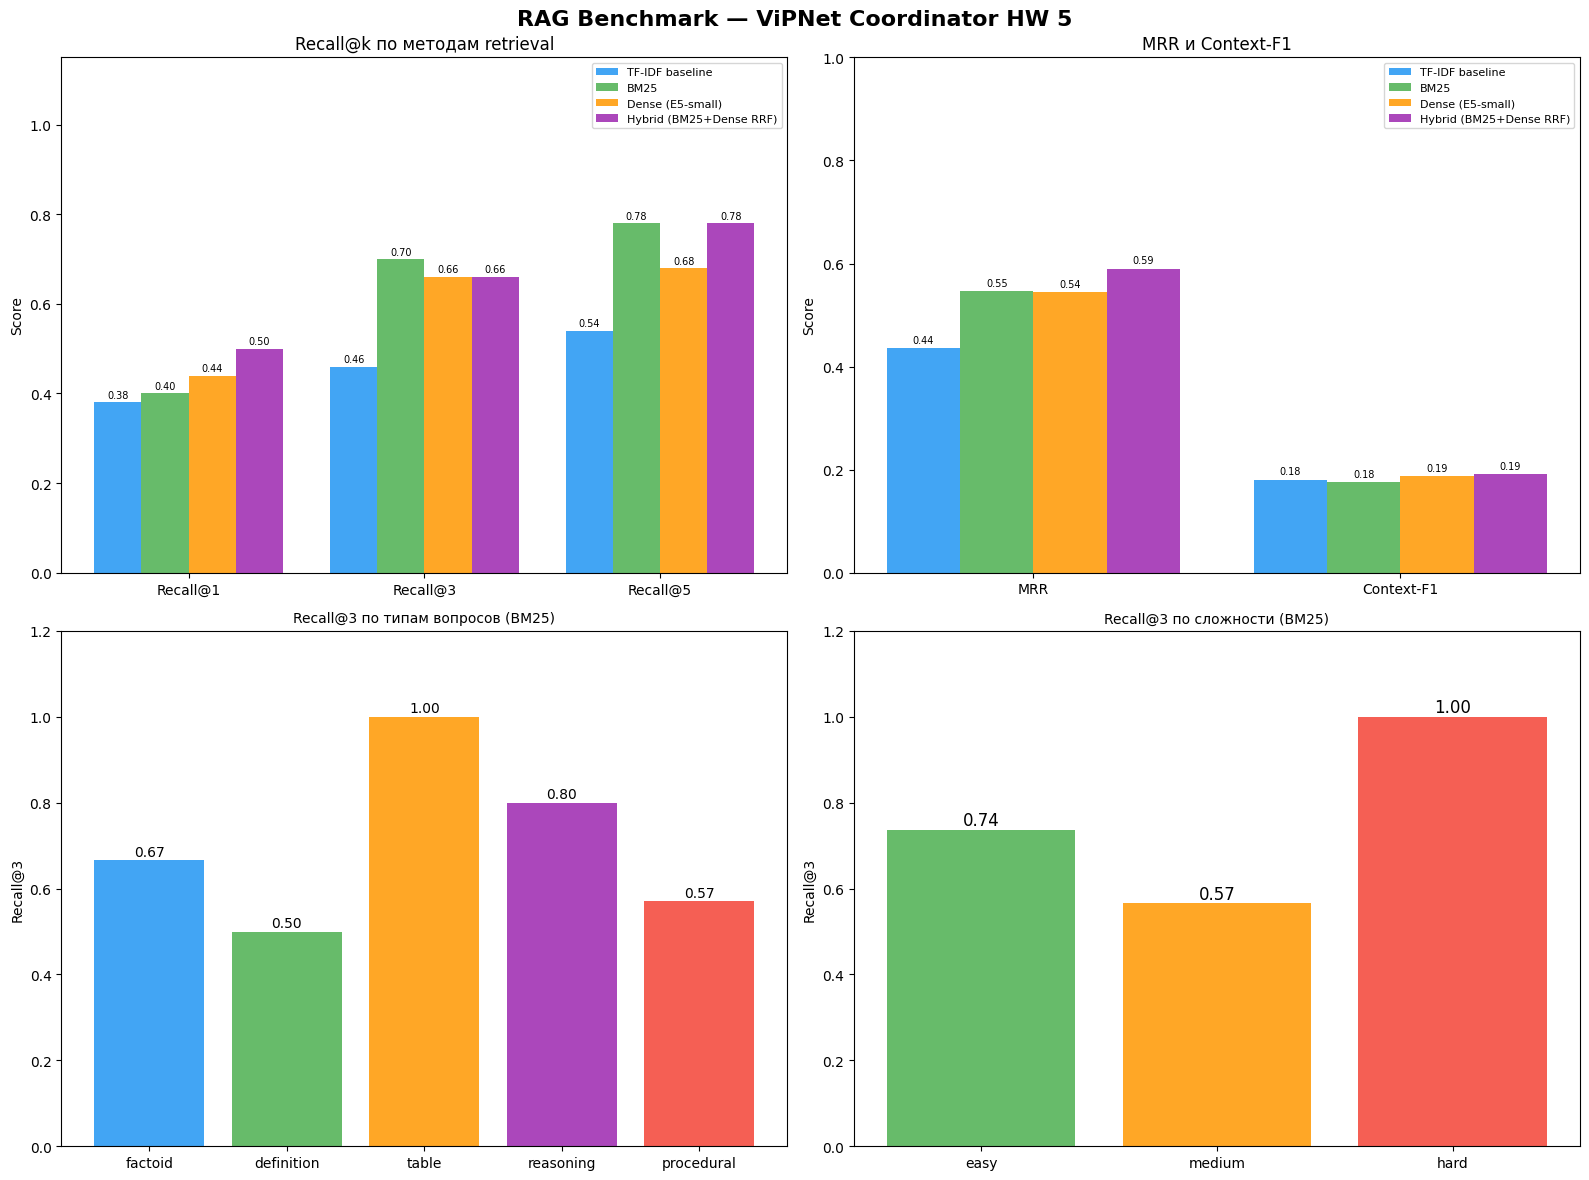

График сохранён: benchmark_results.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('RAG Benchmark — ViPNet Coordinator HW 5', fontsize=16, fontweight='bold')
methods = list(all_results.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
ax = axes[0, 0]
x = np.arange(len(KS))
width = 0.2
for i, (name, (metrics, _)) in enumerate(all_results.items()):
    vals = [metrics[f'Recall@{k}'] for k in KS]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=7)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Recall@{k}' for k in KS])
ax.set_ylim(0, 1.15)
ax.set_title('Recall@k по методам retrieval', fontsize=12)
ax.legend(fontsize=8)
ax.set_ylabel('Score')

ax = axes[0, 1]
metric_names = ['MRR', 'Context-F1']
x = np.arange(len(metric_names))
for i, (name, (metrics, _)) in enumerate(all_results.items()):
    vals = [metrics['MRR'], metrics['Context-F1']]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=7)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.0)
ax.set_title('MRR и Context-F1', fontsize=12)
ax.legend(fontsize=8)
ax.set_ylabel('Score')

ax = axes[1, 0]
best_method = max(all_results.keys(), key=lambda n: all_results[n][0]['Recall@3'])
_, best_results = all_results[best_method]

q_types = ['factoid', 'definition', 'table', 'reasoning', 'procedural']
recall_by_type = {}
for qt in q_types:
    qs = [q for q in BENCHMARK if q['q_type'] == qt]
    r3 = np.mean([recall_at_k(best_results[q['q_id']], q['gold_chunk_id'], 3) for q in qs])
    recall_by_type[qt] = r3

qt_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = ax.bar(q_types, list(recall_by_type.values()), color=qt_colors, alpha=0.85)
for bar, val in zip(bars, recall_by_type.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=10)
ax.set_ylim(0, 1.2)
ax.set_title(f'Recall@3 по типам вопросов ({best_method})', fontsize=10)
ax.set_ylabel('Recall@3')

ax = axes[1, 1]
difficulties = ['easy', 'medium', 'hard']
recall_by_diff = {}
for diff in difficulties:
    qs = [q for q in BENCHMARK if q['difficulty'] == diff]
    r3 = np.mean([recall_at_k(best_results[q['q_id']], q['gold_chunk_id'], 3) for q in qs])
    recall_by_diff[diff] = r3

diff_colors = ['#4CAF50', '#FF9800', '#F44336']
bars = ax.bar(difficulties, list(recall_by_diff.values()), color=diff_colors, alpha=0.85)
for bar, val in zip(bars, recall_by_diff.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_title(f'Recall@3 по сложности ({best_method})', fontsize=10)
ax.set_ylabel('Recall@3')

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: benchmark_results.png")

## Блок F. Анализ ошибок

In [8]:
def _diagnose_failure(q: dict, results: list, chunks_map: dict) -> str:
    gold = chunks_map.get(q['gold_chunk_id'], {})
    gold_text = gold.get('text', '').lower()
    q_lower = q['question'].lower()

    kw_in_gold = sum(1 for kw in q.get('keywords', []) if kw.lower() in gold_text)
    if kw_in_gold == 0:
        return "Ни одного ключевого слова нет в gold-чанке — возможно wrong gold_id"

    if gold.get('char_count', 0) < 150:
        return "Gold-чанк слишком короткий — отфильтрован из корпуса"

    if q['gold_chunk_id'] not in {c['chunk_id'] for c in CHUNKS}:
        return "Gold-чанк отфильтрован (< 150 символов или дубликат)"

    return "Семантический разрыв: запрос и чанк используют разные термины"

In [10]:
best_name = max(all_results.keys(), key=lambda n: all_results[n][0]['Recall@3'])
best_metrics, best_results_by_q = all_results[best_name]
all_chunks_map = {c['chunk_id']: c for c in ALL_CHILDREN}
failures = []
for q in BENCHMARK:
    results = best_results_by_q[q['q_id']]
    r5 = recall_at_k(results, q['gold_chunk_id'], 5)
    if r5 == 0.0:
        failures.append(q)

print(f"АНАЛИЗ ОШИБОК ({best_name})")
print(f"Провальных вопросов (gold не в top-5): {len(failures)}/{len(BENCHMARK)}")
print(f"По типам: {dict(Counter(q['q_type'] for q in failures))}")
print(f"По сложности: {dict(Counter(q['difficulty'] for q in failures))}")

for q in failures[:5]:
    print(f"\n{'─'*60}")
    print(f"[{q['q_id']}] [{q['q_type']}] [{q['difficulty']}]")
    print(f"Вопрос: {q['question']}")
    print(f"Эталонный ответ: {q['answer'][:150]}")
    gold = all_chunks_map.get(q['gold_chunk_id'])
    if gold:
        print(f"Gold чанк [{q['gold_chunk_id'][:8]}]: {gold['text'][:200]}")

    results = best_results_by_q[q['q_id']]
    top1_id, top1_score = results[0]
    top1 = all_chunks_map.get(top1_id, {})
    print(f"Top-1 [{top1_id[:8]}] score={top1_score:.3f}: {top1.get('text', '')[:200]}")
    print(f"Причина: {_diagnose_failure(q, results, all_chunks_map)}")

АНАЛИЗ ОШИБОК (BM25)
Провальных вопросов (gold не в top-5): 11/50
По типам: {'factoid': 5, 'definition': 3, 'reasoning': 2, 'procedural': 1}
По сложности: {'medium': 6, 'easy': 5}

────────────────────────────────────────────────────────────
[F04] [factoid] [medium]
Вопрос: Какой символ используется для указания идентификатора сетевого узла ViPNet в командном интерпретаторе?
Эталонный ответ: Шестнадцатеричный формат с префиксом 0x
Gold чанк [d8712033]: фигурных скобок:
hostname# inet ntp   mode off

Идентификатор сетевого узла ViPNet указывается в шестнадцатеричном формате с префиксом
0x  :
hostname# iplir ping 0x 270e000a


Что нового в версии 5.3.
Top-1 [8c5606b2] score=19.572: Атрибут     Расшифровка в командном     Пояснение
             интерпретаторе

C           connected                   Маршрут в подсеть, к которой подключен один из интерфейсов
                      
Причина: Семантический разрыв: запрос и чанк используют разные термины

──────────────────────────────────────

## Блок G. Сохранение результатов

In [11]:
from pathlib import Path

OUT = Path('benchmark_output')
OUT.mkdir(exist_ok=True)

with open(OUT / 'qa_dataset.json', 'w', encoding='utf-8') as f:
    json.dump(BENCHMARK, f, ensure_ascii=False, indent=2)

results_export = {}
for name, (metrics, results_by_q) in all_results.items():
    results_export[name] = {
        'metrics': metrics,
        'per_question': {qid: [(cid, score) for cid, score in res[:5]]
                         for qid, res in results_by_q.items()}
    }
with open(OUT / 'experiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_export, f, ensure_ascii=False, indent=2)

df_results.to_csv(OUT / 'summary_table.csv', encoding='utf-8')
detail_rows = []
for q in BENCHMARK:
    row = {'q_id': q['q_id'], 'q_type': q['q_type'], 'difficulty': q['difficulty'],
           'question': q['question'][:80]}
    for name, (metrics, results_by_q) in all_results.items():
        results = results_by_q[q['q_id']]
        row[f'{name[:15]}_R@1'] = recall_at_k(results, q['gold_chunk_id'], 1)
        row[f'{name[:15]}_R@3'] = recall_at_k(results, q['gold_chunk_id'], 3)
        row[f'{name[:15]}_RR']  = round(reciprocal_rank(results, q['gold_chunk_id']), 3)
    detail_rows.append(row)

pd.DataFrame(detail_rows).to_csv(OUT / 'detailed_results.csv', index=False, encoding='utf-8')

print("Файлы сохранены:")
for fpath in sorted(OUT.iterdir()):
    print(f"  {fpath.name:<35} {fpath.stat().st_size:>10,} байт")

print("ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА")
print(df_results.to_string())

Файлы сохранены:
  detailed_results.csv                     9,344 байт
  experiment_results.json                 90,196 байт
  qa_dataset.json                         28,862 байт
  summary_table.csv                          232 байт
ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА
                            MRR  Recall@1  Recall@3  Recall@5  Context-F1
Метод                                                                    
TF-IDF baseline          0.4367      0.38      0.46      0.54      0.1808
BM25                     0.5457      0.40      0.70      0.78      0.1753
Dense (E5-small)         0.5440      0.44      0.66      0.68      0.1884
Hybrid (BM25+Dense RRF)  0.5903      0.50      0.66      0.78      0.1907


## Скачать результаты (Google Colab)

In [12]:
try:
    from google.colab import files
    import zipfile

    zip_path = 'rag_benchmark_results.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fpath in OUT.iterdir():
            zf.write(fpath, fpath.name)
        if Path('benchmark_results.png').exists():
            zf.write('benchmark_results.png')

    files.download(zip_path)
    print(f'Скачан: {zip_path}')
except ImportError:
    print('Файлы доступны в папке benchmark_output/')

Файлы доступны в папке benchmark_output/


---

## Интерпретация результатов

### Метрики

| Метрика | Что измеряет | Хорошее значение |
|---------|-------------|------------------|
| **Recall@1** | Находит ли top-1 результат правильный чанк | > 0.5 |
| **Recall@3** | Находит ли правильный чанк в топ-3 | > 0.7 |
| **Recall@5** | Находит ли правильный чанк в топ-5 | > 0.8 |
| **MRR** | Средний обратный ранг правильного чанка | > 0.6 |
| **Context-F1** | Насколько top-1 чанк лексически близок к ответу | > 0.3 |


Для технической документации на русском языке:
- **TF-IDF** хорош для точных совпадений терминов CLI-команд
- **BM25** лучше для многословных запросов
- **Dense** лучше для семантически близких (но лексически разных) запросов
- **Hybrid** объединяет преимущества обоих подходов